In [1]:
import sys
sys.path.append("../")

In [2]:
%load_ext autoreload
%autoreload 2
from autogluon.timeseries import TimeSeriesDataFrame
import pandas as pd
import numpy as np
from pathlib import Path
from src.data.preprocessor import read_smard_data, read_exchange_rates_data
#from src.core.base import set_seed
from src.core.timeseries_evaluation import get_crps_scores

/Users/louisskowronek/Documents/thesis/master-thesis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Read data

In [2]:
df, mapping = read_smard_data(file_paths=["data/Realisierter_Stromverbrauch_201501010000_202101010000_Stunde.csv",
                                          "data/Realisierter_Stromverbrauch_202101010000_202504240000_Stunde.csv"],
                              selected_time_series=["Netzlast [MWh] Berechnete Auflösungen", 
                                                    "Residuallast [MWh] Berechnete Auflösungen"])

2025-04-27 19:55:26,872 - INFO - preprocessor.py - Starting to read SMARD data files...
2025-04-27 19:55:26,873 - INFO - preprocessor.py - Reading file: data/Realisierter_Stromverbrauch_201501010000_202101010000_Stunde.csv
2025-04-27 19:55:27,041 - INFO - preprocessor.py - Reading file: data/Realisierter_Stromverbrauch_202101010000_202504240000_Stunde.csv
2025-04-27 19:55:27,135 - INFO - preprocessor.py - Total number of rows after concatenation: 90383
2025-04-27 19:55:27,136 - INFO - preprocessor.py - Selected time series: ['Netzlast [MWh] Berechnete Auflösungen', 'Residuallast [MWh] Berechnete Auflösungen']
2025-04-27 19:55:27,137 - INFO - preprocessor.py - Columns retained: ['Netzlast [MWh] Berechnete Auflösungen', 'Residuallast [MWh] Berechnete Auflösungen', 'Datum von']
2025-04-27 19:55:27,141 - INFO - preprocessor.py - Number of rows after removing duplicates: 90373
2025-04-27 19:55:27,144 - INFO - preprocessor.py - Dataframe got melted. Number of rows: 180746
2025-04-27 19:55:27

In [38]:
# alternative time series to consider (Großhandelspreise)
df, mapping = read_smard_data(file_paths=["data/Gro_handelspreise_201501010000_202101010000_Stunde.csv",
                                          "data/Gro_handelspreise_202101010000_202504240000_Stunde.csv"],
                              selected_time_series=None)

2025-04-27 16:21:50,569 - INFO - preprocessor.py - Starting to read SMARD data files...
2025-04-27 16:21:50,569 - INFO - preprocessor.py - Reading file: data/Gro_handelspreise_201501010000_202101010000_Stunde.csv
2025-04-27 16:21:50,717 - INFO - preprocessor.py - Reading file: data/Gro_handelspreise_202101010000_202504240000_Stunde.csv
2025-04-27 16:21:50,834 - INFO - preprocessor.py - Total number of rows after concatenation: 90383
2025-04-27 16:21:50,836 - INFO - preprocessor.py - No timeseries selected. Keeping all columns.
2025-04-27 16:21:50,843 - INFO - preprocessor.py - Number of rows after removing duplicates: 90373
2025-04-27 16:21:50,864 - INFO - preprocessor.py - Dataframe got melted. Number of rows: 1536341
2025-04-27 16:21:50,930 - INFO - preprocessor.py - Encoded 17 unique time series.
2025-04-27 16:21:50,931 - INFO - preprocessor.py - Mapped the time series to unique ids: {0: 'Deutschland/Luxemburg [€/MWh] Originalauflösungen', 1: '∅ Anrainer DE/LU [€/MWh] Originalauflös

In [3]:
data = TimeSeriesDataFrame(df)

In [3]:
data, mapping, freq = read_exchange_rates_data(files_dir="../data/exchange_rates/")

2025-06-01 19:38:42,816 - INFO - preprocessor.py - Reading exchange rates data...
2025-06-01 19:38:42,817 - INFO - preprocessor.py - Reading file: ../data/exchange_rates/DEXCAUS.csv
2025-06-01 19:38:42,824 - INFO - preprocessor.py - Reading file: ../data/exchange_rates/DEXCHUS.csv
2025-06-01 19:38:42,829 - INFO - preprocessor.py - Reading file: ../data/exchange_rates/DEXJPUS.csv
2025-06-01 19:38:42,833 - INFO - preprocessor.py - Reading file: ../data/exchange_rates/DEXSIUS.csv
2025-06-01 19:38:42,838 - INFO - preprocessor.py - Reading file: ../data/exchange_rates/DEXSZUS.csv
2025-06-01 19:38:42,843 - INFO - preprocessor.py - Reading file: ../data/exchange_rates/DEXUSAL.csv
2025-06-01 19:38:42,847 - INFO - preprocessor.py - Reading file: ../data/exchange_rates/DEXUSNZ.csv
2025-06-01 19:38:42,851 - INFO - preprocessor.py - Reading file: ../data/exchange_rates/DEXUSUK.csv
2025-06-01 19:38:42,856 - INFO - preprocessor.py - Total rows after concatenation: 9214
2025-06-01 19:38:42,858 - INFO

# Predictions

In [4]:
from src.postprocessors.mle import PostprocessorMLE
from src.postprocessors.qr import PostprocessorQR
from src.predictors.quantile_regression import QuantileRegression
from src.pipeline.pipeline import ForecastingPipeline
from src.predictors.chronos import Chronos
from autogluon.timeseries import TimeSeriesPredictor
from src.core.timeseries_evaluation import get_quantile_scores, get_crps_scores, get_empirical_coverage_rates, get_crps_by_period, plot_crps, load_predictions

2025-06-01 19:38:45,868 - INFO - config.py - PyTorch version 2.5.1 available.


In [5]:
lead_times = [1,4,8,12,24,36,48,60] # could also specify different ones
freq = pd.Timedelta("1h")
quantiles =np.arange(0.1,1,0.1).round(1).tolist()

In [14]:
# chronos zero shot results
pipeline = ForecastingPipeline(model=Chronos, 
                               model_kwargs={"pretrained_model_name_or_path": "amazon/chronos-bolt-tiny", "device_map": "mps", "lead_times": lead_times, "freq": freq}, 
                               postprocessors=[PostprocessorMLE, PostprocessorQR],
                               output_dir=Path("./results/pipeline/chronos-zero-shot"))

results = pipeline.backtest(data=data,
                            test_start_date=pd.Timestamp("01-01-2023"),
                            rolling_window_eval=False,
                            train=False,
                            val_window_size=None,
                            train_window_size=None,
                            test_window_size=None,
                            calibration_based_on="train",
                            save_results=True)

2025-04-27 16:41:51,488 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-04-27 16:41:51,489 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
2025-04-27 16:41:52,217 - INFO - pipeline.py - Start E2E backtesting...
2025-04-27 16:41:52,218 - INFO - pipeline.py - Starting data split operation.
2025-04-27 16:41:52,221 - INFO - pipeline.py - Data split operation completed successfully.
2025-04-27 16:41:52,222 - INFO - pipeline.py - Skipping model training because `train=False`.
2025-04-27 16:41:52,223 - INFO - pipeline.py - Starting postprocessor training with calibration data from 2015-01-01 00:00:00 to 2022-12-31 23:00:00
2025-04-27 16:41:52,223 - INFO - pipeline.py - Running prediction on calibration data using the model: Chronos
Predicting: 100%|██████████| 2192/2192 [01:31<00:00, 24.06it/s]
2025-04-27 16:43:24,965 - INFO - pipeline.py - Calibration predictions completed successfully.
2025-04-27 16:43:24,966 

In [18]:
# chronos full fine tuning
pipeline = ForecastingPipeline(model=Chronos, 
                               model_kwargs={"pretrained_model_name_or_path": "amazon/chronos-bolt-tiny", "device_map": "mps", "lead_times": lead_times, "freq": freq, "finetuning_type": "full", "finetuning_hp_search": False}, 
                               postprocessors=[PostprocessorMLE, PostprocessorQR],
                               output_dir=Path("./results/pipeline/chronos-finetuned-full"))

results = pipeline.backtest(data=data,
                            test_start_date=pd.Timestamp("01-01-2023"),
                            rolling_window_eval=False,
                            train=True,
                            val_window_size=pd.DateOffset(years=1),
                            train_window_size=None,
                            test_window_size=None,
                            calibration_based_on="val",
                            save_results=True)

2025-04-27 20:23:00,869 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-04-27 20:23:00,869 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
2025-04-27 20:23:01,745 - INFO - pipeline.py - Start E2E backtesting...
2025-04-27 20:23:01,746 - INFO - pipeline.py - Starting data split operation.
2025-04-27 20:23:01,751 - INFO - pipeline.py - Data split operation completed successfully.
2025-04-27 20:23:01,752 - INFO - pipeline.py - Starting training process from 2015-01-01 00:00:00 to 2021-12-31 23:00:00
2025-04-27 20:23:01,753 - INFO - pipeline.py - Validation data from 2022-01-01 00:00:00 to 2022-12-31 23:00:00
2025-04-27 20:23:01,753 - INFO - pipeline.py - Initializing predictor with model: Chronos
2025-04-27 20:23:01,753 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-04-27 20:23:01,753 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt

{'eval_loss': 19.744646072387695, 'eval_runtime': 13.7667, 'eval_samples_per_second': 1272.494, 'eval_steps_per_second': 39.806, 'epoch': 0}
{'loss': 18.5194, 'grad_norm': 136.25209045410156, 'learning_rate': 2.604166666666667e-06, 'epoch': 0.026068821689259645}
{'eval_loss': 19.457763671875, 'eval_runtime': 13.7271, 'eval_samples_per_second': 1276.165, 'eval_steps_per_second': 39.921, 'epoch': 0.026068821689259645}
{'loss': 18.249, 'grad_norm': 94.58467864990234, 'learning_rate': 5.208333333333334e-06, 'epoch': 0.05213764337851929}
{'eval_loss': 19.053539276123047, 'eval_runtime': 13.3667, 'eval_samples_per_second': 1310.573, 'eval_steps_per_second': 40.997, 'epoch': 0.05213764337851929}
{'loss': 18.1277, 'grad_norm': 114.85201263427734, 'learning_rate': 7.8125e-06, 'epoch': 0.07820646506777894}
{'eval_loss': 18.787120819091797, 'eval_runtime': 14.0551, 'eval_samples_per_second': 1246.384, 'eval_steps_per_second': 38.99, 'epoch': 0.07820646506777894}
{'loss': 18.0778, 'grad_norm': 91.

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].
2025-04-27 20:35:50,579 - INFO - chronos.py - Saved fine-tuned model to results/pipeline/chronos-finetuned-full/models/finetuned-full/fine-tuned-ckpt.
2025-04-27 20:35:50,580 - INFO - chronos.py - Loading Chronos pipeline from model: results/pipeline/chronos-finetuned-full/models/finetuned-full/fine-tuned-ckpt
2025-04-27 20:35:50,581 - INFO - chronos.py - Initializing Chronos pipeline with model: results/pipeline/chronos-finetuned-full/models/finetuned-full/fine-tuned-ckpt


{'eval_loss': 18.065818786621094, 'eval_runtime': 13.6433, 'eval_samples_per_second': 1284.002, 'eval_steps_per_second': 40.166, 'epoch': 0.886339937434828}
{'train_runtime': 764.8416, 'train_samples_per_second': 160.454, 'train_steps_per_second': 5.015, 'train_loss': 17.043548153147977, 'epoch': 0.886339937434828}


2025-04-27 20:35:50,768 - INFO - chronos.py - Trained model is automatically loaded from checkpoint.
2025-04-27 20:35:50,769 - INFO - pipeline.py - Training completed in 769.017216 seconds.
2025-04-27 20:35:50,770 - INFO - pipeline.py - Starting postprocessor training with calibration data from 2022-01-01 00:00:00 to 2022-12-31 23:00:00
2025-04-27 20:35:50,770 - INFO - pipeline.py - Running prediction on calibration data using the model: Chronos
Predicting: 100%|██████████| 274/274 [00:11<00:00, 23.06it/s]
2025-04-27 20:36:02,692 - INFO - pipeline.py - Calibration predictions completed successfully.
2025-04-27 20:36:02,693 - INFO - pipeline.py - Initializing postprocessor: PostprocessorMLE
2025-04-27 20:36:02,693 - INFO - pipeline.py - Fitting postprocessor: PostprocessorMLE
100%|██████████| 8/8 [00:00<00:00,  8.49it/s]
2025-04-27 20:36:03,636 - INFO - pipeline.py - Successfully fitted postprocessor: PostprocessorMLE
2025-04-27 20:36:03,637 - INFO - pipeline.py - Initializing postproce

In [17]:
# chronos last layer fine tuning
pipeline = ForecastingPipeline(model=Chronos, 
                               model_kwargs={"pretrained_model_name_or_path": "amazon/chronos-bolt-tiny", "device_map": "mps", "lead_times": lead_times, "freq": freq, "finetuning_type": "last_layer", "finetuning_hp_search": False}, 
                               postprocessors=[PostprocessorMLE, PostprocessorQR],
                               output_dir=Path("./results/pipeline/chronos-finetuned-last-layer"))

results = pipeline.backtest(data=data,
                            test_start_date=pd.Timestamp("01-01-2023"),
                            rolling_window_eval=False,
                            train=True,
                            val_window_size=pd.DateOffset(years=1),
                            train_window_size=None,
                            test_window_size=None,
                            calibration_based_on="val",
                            save_results=True)

2025-04-27 20:08:53,142 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-04-27 20:08:53,143 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
2025-04-27 20:08:53,931 - INFO - pipeline.py - Start E2E backtesting...
2025-04-27 20:08:53,933 - INFO - pipeline.py - Starting data split operation.
2025-04-27 20:08:53,938 - INFO - pipeline.py - Data split operation completed successfully.
2025-04-27 20:08:53,939 - INFO - pipeline.py - Starting training process from 2015-01-01 00:00:00 to 2021-12-31 23:00:00
2025-04-27 20:08:53,939 - INFO - pipeline.py - Validation data from 2022-01-01 00:00:00 to 2022-12-31 23:00:00
2025-04-27 20:08:53,939 - INFO - pipeline.py - Initializing predictor with model: Chronos
2025-04-27 20:08:53,940 - INFO - chronos.py - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-04-27 20:08:53,940 - INFO - chronos.py - Initializing Chronos pipeline with model: amazon/chronos-bolt

{'eval_loss': 19.744646072387695, 'eval_runtime': 13.4982, 'eval_samples_per_second': 1297.804, 'eval_steps_per_second': 40.598, 'epoch': 0}
{'loss': 18.6901, 'grad_norm': 20.345304489135742, 'learning_rate': 2.604166666666667e-06, 'epoch': 0.026068821689259645}
{'eval_loss': 19.734594345092773, 'eval_runtime': 13.7055, 'eval_samples_per_second': 1278.175, 'eval_steps_per_second': 39.984, 'epoch': 0.026068821689259645}
{'loss': 18.8273, 'grad_norm': 18.67915916442871, 'learning_rate': 5.208333333333334e-06, 'epoch': 0.05213764337851929}
{'eval_loss': 19.70655632019043, 'eval_runtime': 13.3354, 'eval_samples_per_second': 1313.645, 'eval_steps_per_second': 41.094, 'epoch': 0.05213764337851929}
{'loss': 18.9222, 'grad_norm': 19.813947677612305, 'learning_rate': 7.8125e-06, 'epoch': 0.07820646506777894}
{'eval_loss': 19.686559677124023, 'eval_runtime': 13.3727, 'eval_samples_per_second': 1309.986, 'eval_steps_per_second': 40.979, 'epoch': 0.07820646506777894}
{'loss': 19.0386, 'grad_norm':

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].
2025-04-27 20:19:43,834 - INFO - chronos.py - Saved fine-tuned model to results/pipeline/chronos-finetuned-last-layer/models/finetuned-last_layer/fine-tuned-ckpt.
2025-04-27 20:19:43,835 - INFO - chronos.py - Loading Chronos pipeline from model: results/pipeline/chronos-finetuned-last-layer/models/finetuned-last_layer/fine-tuned-ckpt
2025-04-27 20:19:43,835 - INFO - chronos.py - Initializing Chronos pipeline with model: results/pipeline/chronos-finetuned-last-layer/models/finetuned-last_layer/fine-tuned-ckpt


{'train_runtime': 645.7929, 'train_samples_per_second': 190.033, 'train_steps_per_second': 5.94, 'train_loss': 18.608009266778748, 'epoch': 1.0}


2025-04-27 20:19:44,003 - INFO - chronos.py - Trained model is automatically loaded from checkpoint.
2025-04-27 20:19:44,004 - INFO - pipeline.py - Training completed in 650.065808 seconds.
2025-04-27 20:19:44,005 - INFO - pipeline.py - Starting postprocessor training with calibration data from 2022-01-01 00:00:00 to 2022-12-31 23:00:00
2025-04-27 20:19:44,005 - INFO - pipeline.py - Running prediction on calibration data using the model: Chronos
Predicting: 100%|██████████| 274/274 [00:10<00:00, 25.12it/s]
2025-04-27 20:19:54,952 - INFO - pipeline.py - Calibration predictions completed successfully.
2025-04-27 20:19:54,952 - INFO - pipeline.py - Initializing postprocessor: PostprocessorMLE
2025-04-27 20:19:54,952 - INFO - pipeline.py - Fitting postprocessor: PostprocessorMLE
100%|██████████| 8/8 [00:00<00:00,  9.28it/s]
2025-04-27 20:19:55,816 - INFO - pipeline.py - Successfully fitted postprocessor: PostprocessorMLE
2025-04-27 20:19:55,816 - INFO - pipeline.py - Initializing postproce

In [14]:
# chronos LoRa tuning
pipeline = ForecastingPipeline(model=Chronos, 
                               model_kwargs={"pretrained_model_name_or_path": "amazon/chronos-bolt-tiny", "device_map": "mps", "lead_times": lead_times, "freq": freq, "finetuning_type": "LoRa", "finetuning_hp_search": False}, 
                               postprocessors=[PostprocessorMLE, PostprocessorQR],
                               output_dir=Path("./results/pipeline/chronos-finetuned-lora"))

results = pipeline.backtest(data=data,
                            test_start_date=pd.Timestamp("01-01-2023"),
                            rolling_window_eval=False,
                            train=True,
                            val_window_size=pd.DateOffset(years=1),
                            train_window_size=None,
                            test_window_size=None,
                            calibration_based_on="val",
                            save_results=True)

2025-04-27 19:22:29,173 - INFO - <string> - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-04-27 19:22:29,174 - INFO - <string> - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
2025-04-27 19:22:29,999 - INFO - pipeline.py - Start E2E backtesting...
2025-04-27 19:22:30,000 - INFO - pipeline.py - Starting data split operation.
2025-04-27 19:22:30,006 - INFO - pipeline.py - Data split operation completed successfully.
2025-04-27 19:22:30,007 - INFO - pipeline.py - Starting training process from 2015-01-01 00:00:00 to 2021-12-31 23:00:00
2025-04-27 19:22:30,007 - INFO - pipeline.py - Validation data from 2022-01-01 00:00:00 to 2022-12-31 23:00:00
2025-04-27 19:22:30,008 - INFO - pipeline.py - Initializing predictor with model: Chronos
2025-04-27 19:22:30,008 - INFO - <string> - Loading Chronos pipeline from model: amazon/chronos-bolt-tiny
2025-04-27 19:22:30,008 - INFO - <string> - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
20

trainable params: 411,136 || all params: 9,063,808 || trainable%: 4.5360
trainable params: 411,136 || all params: 9,063,808 || trainable%: 4.5360
{'eval_loss': 19.744646072387695, 'eval_runtime': 22.0301, 'eval_samples_per_second': 795.185, 'eval_steps_per_second': 24.875, 'epoch': 0}


Could not estimate the number of tokens of the input, floating-point operations will not be computed


{'loss': 18.6837, 'grad_norm': 31.332416534423828, 'learning_rate': 2.604166666666667e-06, 'epoch': 0.026068821689259645}
{'eval_loss': 19.719966888427734, 'eval_runtime': 21.7019, 'eval_samples_per_second': 807.21, 'eval_steps_per_second': 25.251, 'epoch': 0.026068821689259645}
{'loss': 18.7748, 'grad_norm': 22.093442916870117, 'learning_rate': 5.208333333333334e-06, 'epoch': 0.05213764337851929}
{'eval_loss': 19.644203186035156, 'eval_runtime': 21.726, 'eval_samples_per_second': 806.315, 'eval_steps_per_second': 25.223, 'epoch': 0.05213764337851929}
{'loss': 18.7872, 'grad_norm': 24.133670806884766, 'learning_rate': 7.8125e-06, 'epoch': 0.07820646506777894}
{'eval_loss': 19.544843673706055, 'eval_runtime': 21.024, 'eval_samples_per_second': 833.238, 'eval_steps_per_second': 26.065, 'epoch': 0.07820646506777894}
{'loss': 18.8352, 'grad_norm': 16.80287742614746, 'learning_rate': 9.953650057937429e-06, 'epoch': 0.10427528675703858}
{'eval_loss': 19.44805908203125, 'eval_runtime': 20.538

2025-04-27 19:43:25,598 - INFO - chronos.py - Saved fine-tuned model to results/pipeline/chronos-finetuned-lora/models/finetuned-LoRa/fine-tuned-ckpt.
2025-04-27 19:43:25,600 - INFO - <string> - Loading Chronos pipeline from model: results/pipeline/chronos-finetuned-lora/models/finetuned-LoRa/fine-tuned-ckpt
2025-04-27 19:43:25,600 - INFO - <string> - Found LoRa configuration in results/pipeline/chronos-finetuned-lora/models/finetuned-LoRa/fine-tuned-ckpt.
2025-04-27 19:43:25,601 - INFO - <string> - Base model name: amazon/chronos-bolt-tiny
2025-04-27 19:43:25,601 - INFO - <string> - Initializing Chronos pipeline with model: amazon/chronos-bolt-tiny
2025-04-27 19:43:30,332 - INFO - <string> - LoRa adapters applied successfully.
2025-04-27 19:43:30,332 - INFO - chronos.py - Trained model is automatically loaded from checkpoint.
2025-04-27 19:43:30,333 - INFO - pipeline.py - Training completed in 1260.326656 seconds.
2025-04-27 19:43:30,334 - INFO - pipeline.py - Starting postprocessor t

In [11]:
# Nearest neighbour predictor
pipeline = ForecastingPipeline(model=NNPredictor, 
                               model_kwargs={"quantiles": quantiles, "lead_times": lead_times, "freq": freq}, 
                               postprocessors=[PostprocessorQR, PostprocessorMLE],
                               output_dir=Path("./results/pipeline/benchmark_nn"))

results = pipeline.backtest(test_start_date=pd.Timestamp("01-01-2023"),
                            data=data,
                            rolling_window_eval=False,
                            train=True,
                            val_window_size=None,
                            train_window_size=None,
                            test_window_size=None,
                            calibration_based_on="train",
                            save_results=True)

2025-04-27 19:57:25,021 - INFO - pipeline.py - Start E2E backtesting...
2025-04-27 19:57:25,023 - INFO - pipeline.py - Starting data split operation.
2025-04-27 19:57:25,027 - INFO - pipeline.py - Data split operation completed successfully.
2025-04-27 19:57:25,028 - INFO - pipeline.py - Starting training process from 2015-01-01 00:00:00 to 2022-12-31 23:00:00
2025-04-27 19:57:25,028 - INFO - pipeline.py - No validation data provided.
2025-04-27 19:57:25,029 - INFO - pipeline.py - Initializing predictor with model: NNPredictor
2025-04-27 19:57:25,029 - INFO - pipeline.py - Fitting predictor to the training data...
2025-04-27 19:57:25,029 - INFO - nearest_neighbour.py - No fit needed. Can call predict directly. Only provide previous_context_data when calling predict().
2025-04-27 19:57:25,029 - INFO - pipeline.py - Training completed in 0.001863 seconds.
2025-04-27 19:57:25,031 - INFO - pipeline.py - Starting postprocessor training with calibration data from 2015-01-01 00:00:00 to 2022-

In [12]:
# quantile regression
pipeline = ForecastingPipeline(model=QuantileRegression, 
                               model_kwargs={"quantiles": quantiles, "lead_times": lead_times, "freq": freq}, 
                               postprocessors=[PostprocessorQR, PostprocessorMLE],
                               output_dir=Path("./results/pipeline/benchmark_qr"))

results = pipeline.backtest(test_start_date=pd.Timestamp("01-01-2023"),
                            data=data,
                            rolling_window_eval=False,
                            train=True,
                            val_window_size=None,
                            train_window_size=None,
                            test_window_size=None,
                            calibration_based_on="train",
                            save_results=True)

2025-04-27 19:59:51,538 - INFO - pipeline.py - Start E2E backtesting...
2025-04-27 19:59:51,539 - INFO - pipeline.py - Starting data split operation.
2025-04-27 19:59:51,542 - INFO - pipeline.py - Data split operation completed successfully.
2025-04-27 19:59:51,544 - INFO - pipeline.py - Starting training process from 2015-01-01 00:00:00 to 2022-12-31 23:00:00
2025-04-27 19:59:51,544 - INFO - pipeline.py - No validation data provided.
2025-04-27 19:59:51,544 - INFO - pipeline.py - Initializing predictor with model: QuantileRegression
2025-04-27 19:59:51,544 - INFO - pipeline.py - Fitting predictor to the training data...
100%|██████████| 8/8 [04:08<00:00, 31.02s/it]
2025-04-27 20:03:59,712 - INFO - pipeline.py - Training completed in 248.16952 seconds.
2025-04-27 20:03:59,718 - INFO - pipeline.py - Starting postprocessor training with calibration data from 2015-01-01 00:00:00 to 2022-12-31 23:00:00
2025-04-27 20:03:59,723 - INFO - pipeline.py - Running prediction on calibration data us

In [19]:
results = load_predictions("./results/pipeline/")

2025-04-27 20:39:46,596 - INFO - timeseries_evaluation.py - Loading predictions by searching in provided directories...
2025-04-27 20:39:46,600 - INFO - timeseries_evaluation.py - Common path identified: results/pipeline
2025-04-27 20:39:46,813 - INFO - timeseries_evaluation.py - Loaded prediction file: `results/pipeline/chronos-finetuned-lora/backtest/Chronos/predictions.joblib` as key: chronos-finetuned-lora_Chronos
2025-04-27 20:39:46,828 - INFO - timeseries_evaluation.py - Loaded prediction file: `results/pipeline/chronos-finetuned-lora/backtest/PostprocessorQR/predictions.joblib` as key: chronos-finetuned-lora_PostprocessorQR
2025-04-27 20:39:46,837 - INFO - timeseries_evaluation.py - Loaded prediction file: `results/pipeline/chronos-finetuned-lora/backtest/PostprocessorMLE/predictions.joblib` as key: chronos-finetuned-lora_PostprocessorMLE
2025-04-27 20:39:47,072 - INFO - timeseries_evaluation.py - Loaded prediction file: `results/pipeline/chronos-zero-shot/backtest/Chronos/predi

In [ ]:
get_quantile_scores(results, reference_predictions="chronos-zero-shot_Chronos")

,chronos-finetuned-lora_Chronos,chronos-finetuned-lora_PostprocessorQR,chronos-finetuned-lora_PostprocessorMLE,chronos-zero-shot_Chronos,chronos-zero-shot_PostprocessorQR,chronos-zero-shot_PostprocessorMLE,chronos-finetuned-last-layer_Chronos,chronos-finetuned-last-layer_PostprocessorQR,chronos-finetuned-last-layer_PostprocessorMLE,benchmark_nn_PostprocessorQR,benchmark_nn_PostprocessorMLE,benchmark_nn_NNPredictor,chronos-finetuned-full_Chronos,chronos-finetuned-full_PostprocessorQR,chronos-finetuned-full_PostprocessorMLE,benchmark_qr_PostprocessorQR,benchmark_qr_PostprocessorMLE,benchmark_qr_QuantileRegression
quantile,,,,,,,,,,,,,,,,,,
0.1,0.978817,0.948997,0.959730,1.0,0.975729,0.991383,0.982300,0.960085,0.972286,1.563280,1.558683,1.704837,0.930973,0.907583,0.919430,2.350257,2.498557,2.353213
0.2,0.973153,0.957841,0.963047,1.0,0.987822,0.994774,0.985358,0.973107,0.980305,1.568093,1.555895,1.616242,0.939321,0.925715,0.928550,2.360988,2.340682,2.362290
0.3,0.968454,0.960092,0.962910,1.0,0.993526,0.995113,0.985984,0.979061,0.983094,1.559537,1.546391,1.585905,0.940335,0.932377,0.932536,2.332784,2.257237,2.332937
0.4,0.964735,0.959702,0.960984,1.0,0.995864,0.994356,0.985372,0.981426,0.983624,1.555166,1.540523,1.574511,0.939591,0.934042,0.933481,2.301906,2.201164,2.301841
0.5,0.962215,0.958223,0.958562,1.0,0.995792,0.992999,0.984028,0.981132,0.982450,1.553457,1.541654,1.567139,0.937512,0.933004,0.932453,2.266614,2.158180,2.266668
0.6,0.959990,0.954933,0.955287,1.0,0.993680,0.991411,0.982575,0.979150,0.979628,1.553069,1.548761,1.564585,0.933323,0.929144,0.928492,2.222477,2.123163,2.222729
0.7,0.958306,0.949647,0.951370,1.0,0.989444,0.990851,0.980104,0.974385,0.976011,1.541487,1.556355,1.558730,0.927814,0.922083,0.922031,2.168621,2.095772,2.168915
0.8,0.957182,0.941727,0.946628,1.0,0.982989,0.992095,0.976857,0.966795,0.971356,1.512722,1.566348,1.552703,0.920510,0.911932,0.914625,2.104037,2.078817,2.104442
0.9,0.955198,0.929318,0.949244,1.0,0.972498,1.000198,0.968669,0.953423,0.968622,1.453406,1.574540,1.579151,0.907769,0.895547,0.912835,2.007880,2.088332,2.008557


In [22]:
get_crps_scores(results, reference_predictions="chronos-zero-shot_Chronos")

,chronos-finetuned-lora_Chronos,chronos-finetuned-lora_PostprocessorQR,chronos-finetuned-lora_PostprocessorMLE,chronos-zero-shot_Chronos,chronos-zero-shot_PostprocessorQR,chronos-zero-shot_PostprocessorMLE,chronos-finetuned-last-layer_Chronos,chronos-finetuned-last-layer_PostprocessorQR,chronos-finetuned-last-layer_PostprocessorMLE,benchmark_nn_PostprocessorQR,benchmark_nn_PostprocessorMLE,benchmark_nn_NNPredictor,chronos-finetuned-full_Chronos,chronos-finetuned-full_PostprocessorQR,chronos-finetuned-full_PostprocessorMLE,benchmark_qr_PostprocessorQR,benchmark_qr_PostprocessorMLE,benchmark_qr_QuantileRegression
lead times,,,,,,,,,,,,,,,,,,
1,0.961277,0.927886,0.925128,1.0,0.938506,0.934335,0.940017,0.914716,0.911924,5.371023,5.393390,5.502409,0.933240,0.898623,0.896860,7.857141,7.680673,7.855466
4,0.959303,0.954467,0.955201,1.0,0.988984,0.989314,0.973746,0.968121,0.969055,2.450455,2.460677,2.510467,0.892347,0.887431,0.887631,3.532699,3.434563,3.532339
8,0.966530,0.955210,0.957109,1.0,0.985759,0.988283,0.977468,0.969773,0.972147,1.753202,1.760464,1.796164,0.912716,0.907696,0.908286,2.544082,2.478125,2.543971
12,0.965736,0.952638,0.955973,1.0,0.984666,0.988674,0.979680,0.971723,0.974593,1.520582,1.526982,1.557926,0.925770,0.920499,0.921787,2.222346,2.178059,2.222321
24,0.972001,0.960526,0.964313,1.0,0.992079,0.996543,0.989713,0.980308,0.984607,1.322205,1.327888,1.354729,0.950460,0.942038,0.944644,1.921430,1.879652,1.921911
36,0.961093,0.949729,0.954012,1.0,0.992301,0.997208,0.986976,0.979203,0.983674,1.177835,1.183010,1.206879,0.940537,0.931234,0.933319,1.708712,1.671085,1.709400
48,0.961872,0.954031,0.960057,1.0,0.996032,1.001742,0.987050,0.981716,0.988321,1.163630,1.168901,1.192365,0.943122,0.935143,0.938596,1.688484,1.651090,1.689493
60,0.961742,0.953136,0.958732,1.0,0.995716,1.000085,0.984171,0.978437,0.985271,1.121810,1.126953,1.149551,0.936547,0.928483,0.932611,1.636481,1.603572,1.638009


In [6]:
# minimum working example
pipeline = ForecastingPipeline(model=NNPredictor, 
                               model_kwargs={"quantiles": quantiles, "lead_times": lead_times, "freq": freq}, 
                               postprocessors=[PostprocessorMLE],
                               output_dir="./results/pipeline/nearest_neighbour")

data_train, data_val, data_test = pipeline.split_data(data=data, 
                                                      test_start_date=pd.Timestamp("01-01-2022"), 
                                                      train_window_size=None,
                                                      test_window_size=None,
                                                      val_window_size=None)

pipeline.train(data_train)
pipeline.train_postprocessors(calibration_data=data_train)

predictions = pipeline.predict(data_test=data_test, data_previous_context=data_train)
predictions = pipeline.apply_postprocessing(predictions)

pipeline.save()

2025-04-27 14:01:50,367 - INFO - pipeline.py - Starting data split operation.
2025-04-27 14:01:50,376 - INFO - pipeline.py - Data split operation completed successfully.
2025-04-27 14:01:50,378 - INFO - pipeline.py - Starting training process from 2015-01-01 00:00:00 to 2021-12-31 23:00:00
2025-04-27 14:01:50,378 - INFO - pipeline.py - No validation data provided.
2025-04-27 14:01:50,378 - INFO - pipeline.py - Initializing predictor with model: NNPredictor
2025-04-27 14:01:50,378 - INFO - pipeline.py - Fitting predictor to the training data...
2025-04-27 14:01:50,379 - INFO - nearest_neighbour.py - No fit needed. Can call predict directly. Only provide previous_context_data when calling predict().
2025-04-27 14:01:50,379 - INFO - pipeline.py - Training completed in 0.002931 seconds.
2025-04-27 14:01:50,382 - INFO - pipeline.py - Starting postprocessor training with calibration data from 2015-01-01 00:00:00 to 2021-12-31 23:00:00
2025-04-27 14:01:50,382 - INFO - pipeline.py - Running pr

In [7]:
pipe = ForecastingPipeline.from_pretrained(path="./results/pipeline/nearest_neighbour")

2025-04-27 13:57:07,555 - INFO - pipeline.py - Load NNPredictor from <module 'src.predictors.nearest_neighbour' from '/Users/louisskowronek/Documents/thesis/master-thesis/src/predictors/nearest_neighbour.py'>
2025-04-27 13:57:07,555 - INFO - pipeline.py - Load PostprocessorMLE from <module 'src.postprocessors.mle' from '/Users/louisskowronek/Documents/thesis/master-thesis/src/postprocessors/mle.py'>


### Chronos Bolt Zero Shot

In [ ]:
chronos = Chronos(model_name="amazon/chronos-bolt-tiny",
                  device_map="mps",
                  lead_times=lead_times,
                  freq=freq,
                  )

# get zero shot perdictions on test dataset
predictions_raw = chronos.predict(data=data_test,
                                  previous_context_data=data_train)


Load chronos pipeline.


Predicting: 100%|██████████| 971/971 [00:39<00:00, 24.61it/s]


In [92]:
# get zero shot predictions on training dataset - used for postprocessing later
predictions_train = chronos.predict(data=data_train,
                                    previous_context_data=None)


Predicting: 100%|██████████| 1918/1918 [01:19<00:00, 24.24it/s]


In [93]:
predictions_raw.get_crps(mean_time=True, mean_lead_times=True)

,Mean CRPS
mean,3058.06


In [105]:
predictions_raw.save("data/predictions/realisierter_stromverbrauch/predictions_chronos_raw.joblib")

Saved files to data/predictions/realisierter_stromverbrauch/predictions_chronos_raw.joblib


### Chronos bolt finetuning - via Autogluon Framework

In [5]:
# fine tune using autogluon
predictor = TimeSeriesPredictor(prediction_length=192).fit(train_data=data, presets="chronos_tiny")

No path specified. Models will be saved in: "AutogluonModels/ag-20250601_173853"
Beginning AutoGluon training...
AutoGluon will save models to '/Users/louisskowronek/Documents/thesis/master-thesis/archive/AutogluonModels/ag-20250601_173853'
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.12.10
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 23.6.0: Thu Dec 19 20:47:53 PST 2024; root:xnu-10063.141.1.703.2~1/RELEASE_ARM64_T6030
CPU Count:          12
GPU Count:          0
Memory Avail:       17.38 GB / 36.00 GB (48.3%)
Disk Space Avail:   313.96 GB / 926.35 GB (33.9%)
Setting presets to: chronos_tiny

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'hyperparameters': {'Chronos': {'model_path': 'tiny'}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 192,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,

In [6]:
predictions = predictor.predict(data)

Model not specified in predict, will default to the model with the best validation score: Chronos[tiny]


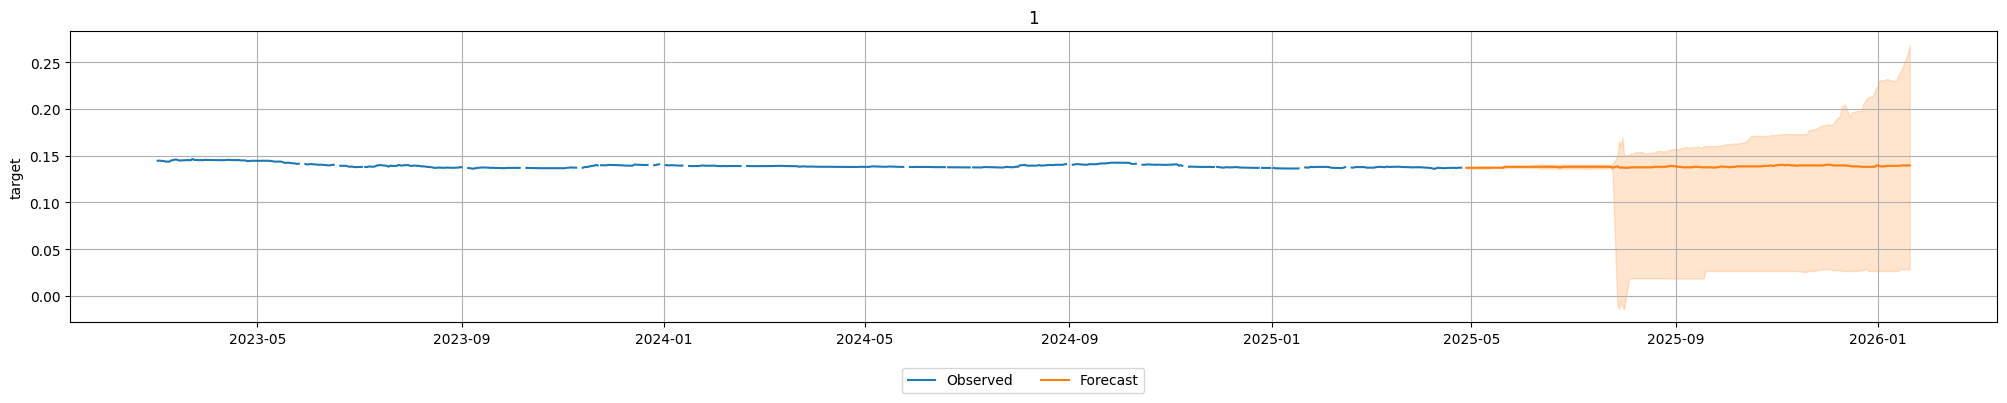

In [10]:
predictor.plot(
    data=data,
    predictions=predictions,
    quantile_levels=[0.1,0.9],
    item_ids=[1],  # Replace with actual item IDs
    max_history_length=562
)

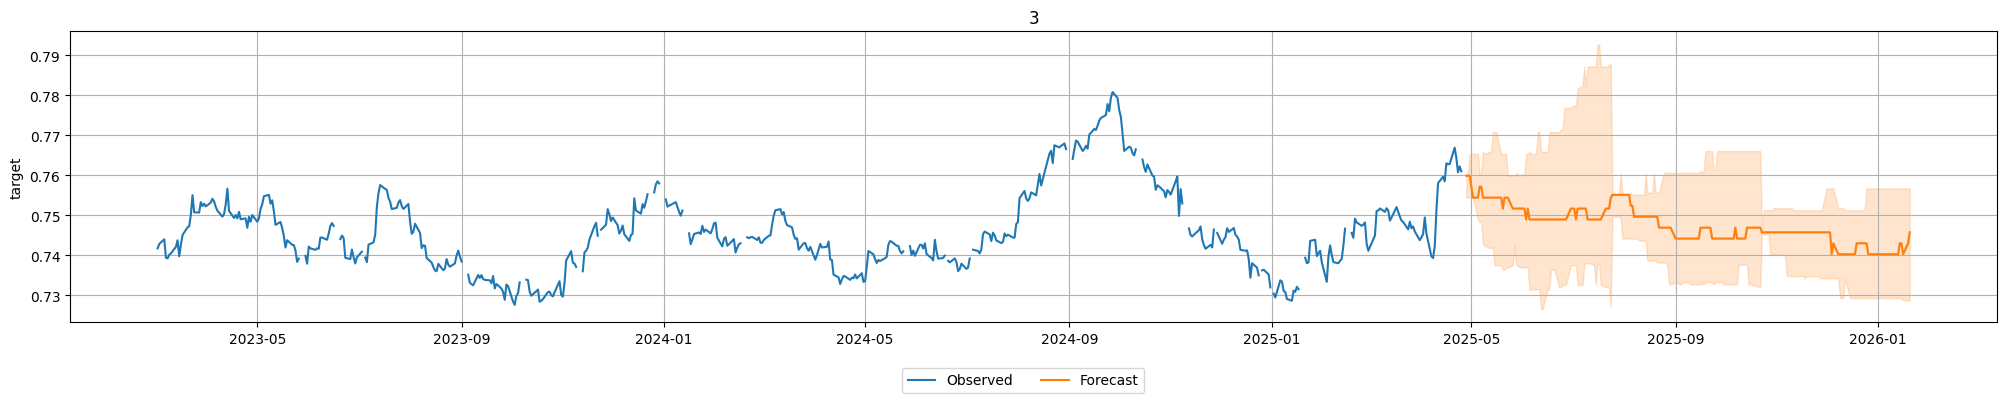

In [19]:
predictor.plot(
    data=data,
    predictions=predictions,
    quantile_levels=[0.1,0.9],
    item_ids=[3],  # Replace with actual item IDs
    max_history_length=562
)

In [3]:
import torch
torch.mps.is_available()

True

In [10]:
predictions

mean       0.1       0.2       0.3       0.4  \
item_id timestamp                                                      
0       2025-04-28  0.722529  0.716381  0.721728  0.721728  0.721728   
        2025-04-29  0.722529  0.716381  0.721728  0.721728  0.721728   
        2025-04-30  0.721460  0.716381  0.716381  0.720124  0.721728   
        2025-05-01  0.720658  0.716381  0.716381  0.716381  0.716381   
        2025-05-02  0.720658  0.716381  0.716381  0.716381  0.716381   
...                      ...       ...       ...       ...       ...   
7       2026-01-14  1.259332  1.216714  1.245750  1.255117  1.255117   
        2026-01-15  1.259332  1.217651  1.245750  1.252307  1.255117   
        2026-01-16  1.258864  1.226081  1.243877  1.245750  1.255117   
        2026-01-19  1.258395  1.216714  1.245750  1.245750  1.251370   
        2026-01-20  1.258864  1.216714  1.245750  1.245750  1.251370   

                         0.5       0.6       0.7       0.8       0.9  
item_id timestamp                                                     
0       2025-04-28  0.721728  0.721728  0.723331  0.727074  0.727074  
        2025-04-29  0.721728  0.721728  0.721728  0.727074  0.727074  
        2025-04-30  0.721728  0.721728  0.721728  0.722797  0.727074  
        2025-05-01  0.719055  0.721728  0.721728  0.722797  0.727608  
        2025-05-02  0.721728  0.721728  0.721728  0.722797  0.727074  
...                      ...       ...       ...       ...       ...  
7       2026-01-14  1.255117  1.258864  1.264483  1.266357  1.287900  
        2026-01-15  1.255117  1.258864  1.264483  1.273850  1.286963  
        2026-01-16  1.255117  1.264483  1.264483  1.266357  1.286963  
        2026-01-19  1.259800  1.264483  1.264483  1.266357  1.286963  
        2026-01-20  1.264483  1.264483  1.264483  1.273850  1.278533  

[1536 rows x 10 columns]

In [ ]:
# fine tune using autogluon
predictor = TimeSeriesPredictor(prediction_length=64, freq="1h").fit(
    train_data=data_train,
    hyperparameters={
        "Chronos": [
            {"model_path": "bolt_tiny", "fine_tune": True, "ag_args": {"name_suffix": "FineTuned"}, "device": "mps"},
        ]
    },
    time_limit=180,  # time limit in seconds
    enable_ensemble=False,
)

Frequency '1h' stored as 'h'
Beginning AutoGluon training... Time limit = 180s
AutoGluon will save models to '/Users/louisskowronek/Documents/thesis/master-thesis/AutogluonModels/ag-20250423_170619'
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.12.7
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 23.6.0: Thu Dec 19 20:47:53 PST 2024; root:xnu-10063.141.1.703.2~1/RELEASE_ARM64_T6030
CPU Count:          12
GPU Count:          0
Memory Avail:       13.81 GB / 36.00 GB (38.4%)
Disk Space Avail:   421.96 GB / 926.35 GB (45.6%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': WQL,
 'freq': 'h',
 'hyperparameters': {'Chronos': [{'ag_args': {'name_suffix': 'FineTuned'},
                                  'device': 'mps',
                                  'fine_tune': True,
                                  'model_path': 'bolt_tiny'}]},
 'known_covariates_names': [],
 'num_val_wi

TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=True,
dispatch_batches=None,
do_eval=False,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.NO,
eval_use

	Saving fine-tuned model to /Users/louisskowronek/Documents/thesis/master-thesis/AutogluonModels/ag-20250423_170619/models/ChronosFineTuned[bolt_tiny]/W0/fine-tuned-ckpt
	-0.2127       = Validation score (-WQL)
	94.38   s     = Training runtime
	0.02    s     = Validation (prediction) runtime
Training complete. Models trained: ['ChronosFineTuned[bolt_tiny]']
Total runtime: 94.41 s
Best model: ChronosFineTuned[bolt_tiny]
Best model score: -0.2127


In [104]:
chronos = Chronos(model_name="./AutogluonModels/ag-20250423_170619/models/ChronosFineTuned[bolt_tiny]/W0/fine-tuned-ckpt",
                  device_map="mps",
                  lead_times=lead_times,
                  freq=freq)

# get zero shot perdictions on test dataset
predictions_finetuned_autogluon = chronos.predict(data=data_test, 
                                                  previous_context_data=data_train)

Load chronos pipeline.


Predicting: 100%|██████████| 971/971 [00:39<00:00, 24.60it/s]


In [107]:
predictions_finetuned_autogluon.get_crps(mean_lead_times=True, mean_time=True)

,Mean CRPS
mean,2879.95


In [109]:
predictions_finetuned_autogluon.save("data/predictions/realisierter_stromverbrauch/predictions_finetuned_autogluon.joblib")

Saved files to data/predictions/realisierter_stromverbrauch/predictions_finetuned_autogluon.joblib


### Chronos Finetuning - own implementation

- still uses elements from the autogluon library
- allows full fine tuning, last layer finetuning, LoRa parameter efficient finetuning
- hyperparameter tuning with autogluon
- logs results with tensorboard


In [110]:
from src.predictors.chronos import fine_tune, model_init_full_tuning, model_init_last_layer_tuning, model_init_lora

In [113]:
# split train data further into train and validation data
data_chronos_train, data_chronos_val = data_train.split_by_time(pd.Timestamp("07-01-2021"))

### full fine tuning

In [115]:
fine_tune(model_init=model_init_full_tuning, 
          data_train=data_chronos_train, 
          data_val=data_chronos_val,
          path=Path("./models/test-full-finetuning/"),
          hp_tuning=False,
          n_trials=10)

Final training hyperparameters:
--------------------------------------------------
TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=True,
dispatch_batches=None,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,

In [116]:
chronos = Chronos(model_name="./models/test-full-finetuning/fine-tuned-ckpt",
                  device_map="mps",
                  lead_times=lead_times,
                  freq=freq)

predictions_full_finetuned = chronos.predict(data=data_test,
                                             previous_context_data=data_train)

Load chronos pipeline.


Predicting: 100%|██████████| 971/971 [02:27<00:00,  6.56it/s]


In [117]:
predictions_full_finetuned.get_crps(mean_lead_times=True, mean_time=True)

,Mean CRPS
mean,2781.4


In [ ]:
predictions_full_finetuned.save("data/predictions/realisierter_stromverbrauch/predictions_full_finetuned.joblib")

Saved files to data/predictions/realisierter_stromverbrauch/predictions_full_finetuned.joblib


### last layer finetuning

In [121]:
fine_tune(model_init=model_init_last_layer_tuning, 
          data_train=data_chronos_train, 
          data_val=data_chronos_val,
          path=Path("./models/test-last-layer-finetuning/"),
          hp_tuning=False,
          n_trials=10)

Final training hyperparameters:
--------------------------------------------------
TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=True,
dispatch_batches=None,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,

In [122]:
chronos = Chronos(model_name="./models/test-last-layer-finetuning/fine-tuned-ckpt",
                  device_map="mps",
                  lead_times=lead_times,
                  freq=freq)

predictions_last_layer_finetuned = chronos.predict(data=data_test,
                                                   previous_context_data=data_train)

Load chronos pipeline.


Predicting: 100%|██████████| 971/971 [00:39<00:00, 24.39it/s]


In [123]:
predictions_last_layer_finetuned.get_crps(mean_lead_times=True, mean_time=True)

,Mean CRPS
mean,3007.72


In [124]:
predictions_last_layer_finetuned.save("data/predictions/realisierter_stromverbrauch/predictions_last_layer_finetuned.joblib")

Saved files to data/predictions/realisierter_stromverbrauch/predictions_last_layer_finetuned.joblib


### LoRa fine tuning

In [125]:
fine_tune(model_init=model_init_lora, 
          data_train=data_chronos_train, 
          data_val=data_chronos_val,
          path=Path("./models/test-lora/"),
          hp_tuning=False,
          n_trials=10)

Final training hyperparameters:
--------------------------------------------------
TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=True,
dispatch_batches=None,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,

In [126]:
chronos = Chronos(model_name="./models/test-lora/fine-tuned-ckpt",
                  device_map="mps",
                  lead_times=lead_times,
                  freq=freq,
                  lora=True)

predictions_lora_finetuned = chronos.predict(data=data_test,
                                             previous_context_data=data_train)

Load chronos pipeline.
Load LoRa weights.


Predicting: 100%|██████████| 971/971 [01:06<00:00, 14.51it/s]


In [127]:
predictions_lora_finetuned.get_crps(mean_lead_times=True, mean_time=True)

,Mean CRPS
mean,2949.09


In [128]:
predictions_lora_finetuned.save("data/predictions/realisierter_stromverbrauch/predictions_lora_finetuned.joblib")

Saved files to data/predictions/realisierter_stromverbrauch/predictions_lora_finetuned.joblib


### Quantile Regression – Benchmark

- simple quantile regresssion with seasonal variables (only calculated based on time information)

In [129]:
from src.predictors.quantile_regression import QuantileRegression

In [130]:
quantreq = QuantileRegression(quantiles = np.arange(0.1, 1, 0.1),
                              lead_times=lead_times,
                              freq=freq)

quantreq.fit(data_train)
predictions_benchmark_qr = quantreq.predict(data_test)

100%|██████████| 8/8 [00:01<00:00,  5.99it/s]


In [131]:
predictions_benchmark_qr.get_crps(mean_lead_times=True, mean_time=True)

,Mean CRPS
mean,6930.87


In [138]:
predictions_benchmark_qr.save("data/predictions/realisierter_stromverbrauch/predictions_benchmark_qr.joblib")

Saved files to data/predictions/realisierter_stromverbrauch/predictions_benchmark_qr.joblib


### Nearest Neigbour Approach - Benchmark
- Berechne empirische Quantile basierend auf den vergangenen Werten des gleichen Wochentags und der gleichen Stunde.

In [139]:
from src.predictors.nearest_neighbour import NNPredictor

In [140]:
nn_predictor = NNPredictor(quantiles = np.arange(0.1, 1, 0.1),
                           lead_times=lead_times,
                           freq=freq)

nn_predictor.fit(data_train)
predictions_benchmark_nn = nn_predictor.predict(data_test)

100%|██████████| 58024/58024 [00:11<00:00, 5068.26it/s]


In [141]:
predictions_benchmark_nn.get_crps(mean_lead_times=True, mean_time=True)

,Mean CRPS
mean,5278.45


In [148]:
predictions_benchmark_nn.save("data/predictions/realisierter_stromverbrauch/predictions_benchmark_nn.joblib")

Saved files to data/predictions/realisierter_stromverbrauch/predictions_benchmark_nn.joblib


In [222]:
from src.predictors.nearest_neighbour import NNPredictor

In [223]:
nn_predictor = NNPredictor(quantiles = np.arange(0.1, 1, 0.1),
                           lead_times=lead_times,
                           freq=freq)

nn_predictor.fit(data_train)
predictions_benchmark_nn = nn_predictor.predict(data_test, data_train)

2025-04-25 13:40:07,332 - INFO - No fit needed. Can call predict directly. Only provide previous_context_data when calling predict().
2025-04-25 13:40:07,334 - INFO - previous_context_data provided. Use this to build the weekday-hour dictionary.
100%|██████████| 58024/58024 [00:10<00:00, 5306.33it/s]


In [224]:
predictions_benchmark_nn.get_crps(item_ids=0, mean_lead_times=True, mean_time=True)

,Mean CRPS
mean,2441.01


In [225]:
predictions_benchmark_nn.get_crps(item_ids=1, mean_lead_times=True, mean_time=True)

,Mean CRPS
mean,7269.28


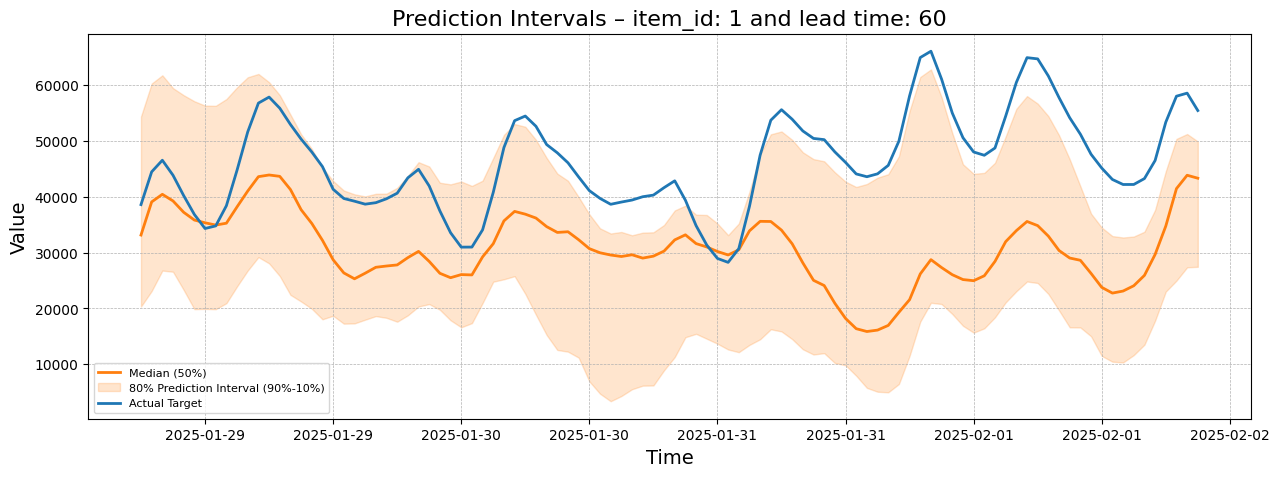

In [208]:
predictions_benchmark_nn.results[60].get_random_plot(item_id=1)

# Postprocessing

### Parametric Approximation of Log-Normal Distribution
- (V1) Fitte Normalverteilung für log Y, mit folgender Parametrisierung: mean = a + b*M, wobei M = Median-Vorhersage des Modells für log Y. Standardabweichung = c + d*IQR, wobei IQR = Interquartilsabstand (z.B. 90%-10%) des Modells für log Y. Falls sich die Modellvorhersagen anfangs auf Y (statt log Y) beziehen kannst Du die einfach logarithmieren, das ist einer der Vorteile von Quantilen.

In [149]:
from src.postprocessors.mle import PostprocessorMLE

In [150]:
postprocessor_mle = PostprocessorMLE()
postprocessor_mle.fit(data=predictions_train)
predictions_post_nrml = postprocessor_mle.postprocess(data=predictions_raw)

100%|██████████| 8/8 [00:00<00:00, 27.56it/s]


In [151]:
predictions_post_nrml.get_crps(mean_time=True, mean_lead_times=True)

,Mean CRPS
mean,3039.33


In [152]:
predictions_post_nrml.save("data/predictions/realisierter_stromverbrauch/predictions_post_mle.joblib")

Saved files to data/predictions/realisierter_stromverbrauch/predictions_post_mle.joblib


### Quantile Regression

-  (V2) Fitte separate Quantilsregression für jedes Quantil (z.B. 10%, 20%, ..., 90%). D.h. für jedes Level eine Quantilsregression mit Konstante und einem Regressor (= Quantils-Vorhersage des Modells). Der Spezialfall mit Konstante = 0 und Slope = 1 würde dann heißen, dass die Vorhersagen bereits perfekt kalibriert sind.



In [153]:
from src.postprocessors.qr import PostprocessorQR

In [154]:
postprocessor_qr = PostprocessorQR()
postprocessor_qr.fit(data=predictions_train)
predictions_post_qr = postprocessor_qr.postprocess(data=predictions_raw)

100%|██████████| 8/8 [00:00<00:00, 16.60it/s]


In [156]:
predictions_post_qr.get_crps(mean_time=True, mean_lead_times=True)

,Mean CRPS
mean,3028.49


In [157]:
predictions_post_qr.save("data/predictions/realisierter_stromverbrauch/predictions_post_qr.joblib")

Saved files to data/predictions/realisierter_stromverbrauch/predictions_post_qr.joblib


# Evaluation

In [ ]:
from src.core.timeseries_evaluation import get_quantile_scores, get_crps_scores, get_empirical_coverage_rates, get_crps_by_period, plot_crps, load_predictions

In [241]:
all_predictions = load_predictions(prediction_dir="data/predictions/realisierter_stromverbrauch")

loaded the following predictions:
------------------------------
predictions_full_finetuned
predictions_last_layer_finetuned
predictions_benchmark_qr
predictions_benchmark_nn
predictions_chronos_raw
predictions_post_qr
predictions_finetuned_autogluon
predictions_lora_finetuned
predictions_post_mle


In [ ]:
get_quantile_scores(all_predictions, 
                    lead_times=None, 
                    item_ids=None, 
                    reference_predictions="predictions_chronos_raw")

,predictions_full_finetuned,predictions_last_layer_finetuned,predictions_benchmark_qr,predictions_benchmark_nn,predictions_chronos_raw,predictions_post_qr,predictions_finetuned_autogluon,predictions_lora_finetuned,predictions_post_mle
quantile,,,,,,,,,
0.1,0.908697,0.984286,2.407478,1.633146,1.0,0.974661,0.947323,0.977538,0.990908
0.2,0.913610,0.986891,2.392431,1.648057,1.0,0.988293,0.950299,0.972147,0.995204
0.3,0.914830,0.987230,2.358244,1.682062,1.0,0.994660,0.949393,0.968309,0.996220
0.4,0.914823,0.986772,2.324926,1.711949,1.0,0.997045,0.946590,0.965035,0.995558
0.5,0.913427,0.985392,2.285312,1.733441,1.0,0.996903,0.943884,0.962719,0.993948
0.6,0.910518,0.983732,2.238548,1.753449,1.0,0.994704,0.940101,0.960924,0.992034
0.7,0.905829,0.981340,2.180365,1.770996,1.0,0.990484,0.935688,0.959463,0.991065
0.8,0.899413,0.977795,2.107759,1.790793,1.0,0.983655,0.930109,0.958040,0.992071
0.9,0.892171,0.970341,1.999784,1.822345,1.0,0.972312,0.922660,0.957296,0.998605


In [ ]:
get_empirical_coverage_rates(all_predictions, 
                             lead_times=None,
                             item_ids=None)

,predictions_full_finetuned,predictions_last_layer_finetuned,predictions_benchmark_qr,predictions_benchmark_nn,predictions_chronos_raw,predictions_post_qr,predictions_finetuned_autogluon,predictions_lora_finetuned,predictions_post_mle
quantile,,,,,,,,,
0.1,0.11,0.11,0.31,0.18,0.11,0.11,0.11,0.11,0.11
0.2,0.21,0.22,0.47,0.30,0.21,0.23,0.21,0.21,0.19
0.3,0.30,0.31,0.59,0.39,0.30,0.33,0.30,0.30,0.29
0.4,0.40,0.40,0.69,0.47,0.40,0.43,0.40,0.39,0.39
0.5,0.49,0.50,0.77,0.54,0.49,0.53,0.49,0.49,0.50
0.6,0.58,0.59,0.84,0.61,0.59,0.63,0.58,0.58,0.61
0.7,0.68,0.68,0.90,0.68,0.69,0.72,0.68,0.68,0.72
0.8,0.78,0.78,0.95,0.74,0.80,0.81,0.78,0.78,0.83
0.9,0.89,0.88,0.98,0.81,0.90,0.90,0.88,0.88,0.92


In [244]:
get_crps_scores(all_predictions, 
                lead_times=None, 
                item_ids=None, 
                reference_predictions="predictions_chronos_raw")

,predictions_full_finetuned,predictions_last_layer_finetuned,predictions_benchmark_qr,predictions_benchmark_nn,predictions_chronos_raw,predictions_post_qr,predictions_finetuned_autogluon,predictions_lora_finetuned,predictions_post_mle
lead times,,,,,,,,,
1,0.770830,0.939981,7.793907,5.896563,1.0,0.939657,0.929955,0.968628,0.934410
4,0.839560,0.974363,3.560634,2.736240,1.0,0.989513,0.924311,0.959446,0.989839
8,0.877407,0.977825,2.573651,1.963132,1.0,0.986303,0.935324,0.965760,0.988965
12,0.896770,0.981008,2.247052,1.701825,1.0,0.985593,0.940536,0.965595,0.989361
24,0.930346,0.990494,1.943688,1.479846,1.0,0.992759,0.952877,0.971481,0.997239
36,0.926454,0.988604,1.723137,1.316050,1.0,0.992873,0.943141,0.961147,0.997771
48,0.940245,0.988596,1.703137,1.300190,1.0,0.996903,0.943862,0.962039,1.002092
60,0.937674,0.986936,1.649309,1.252046,1.0,0.996733,0.944505,0.963192,1.000351


In [230]:
get_crps_by_period(all_predictions, 
                   lead_times=None, 
                   item_ids=None, 
                   reference_predictions="predictions_chronos_raw",
                   date_splits=[pd.Timestamp("01-01-2024"), 
                                pd.Timestamp("01-01-2025")])

,predictions_full_finetuned,predictions_last_layer_finetuned,predictions_benchmark_qr,predictions_benchmark_nn,predictions_chronos_raw,predictions_post_qr,predictions_finetuned_autogluon,predictions_lora_finetuned,predictions_post_mle
2022-01-01 00:00:00_to_2024-01-01 00:00:00,0.904738,0.972019,3.192532,2.353736,1.0,0.993766,0.933104,0.955438,1.017243
2024-01-01 00:00:00_to_2025-01-01 00:00:00,0.928569,0.976445,3.148717,2.221922,1.0,0.991895,0.949699,0.965555,1.010560
2025-01-01 00:00:00_to_2025-04-23 23:00:00,0.944101,0.970891,2.695264,2.521442,1.0,0.990650,0.961260,0.979076,1.011742


In [226]:
selected_keys = [
    'predictions_full_finetuned',
    'predictions_last_layer_finetuned',
    'predictions_chronos_raw',
    'predictions_post_qr',
    'predictions_finetuned_autogluon',
    'predictions_lora_finetuned',
    'predictions_post_mle'
]

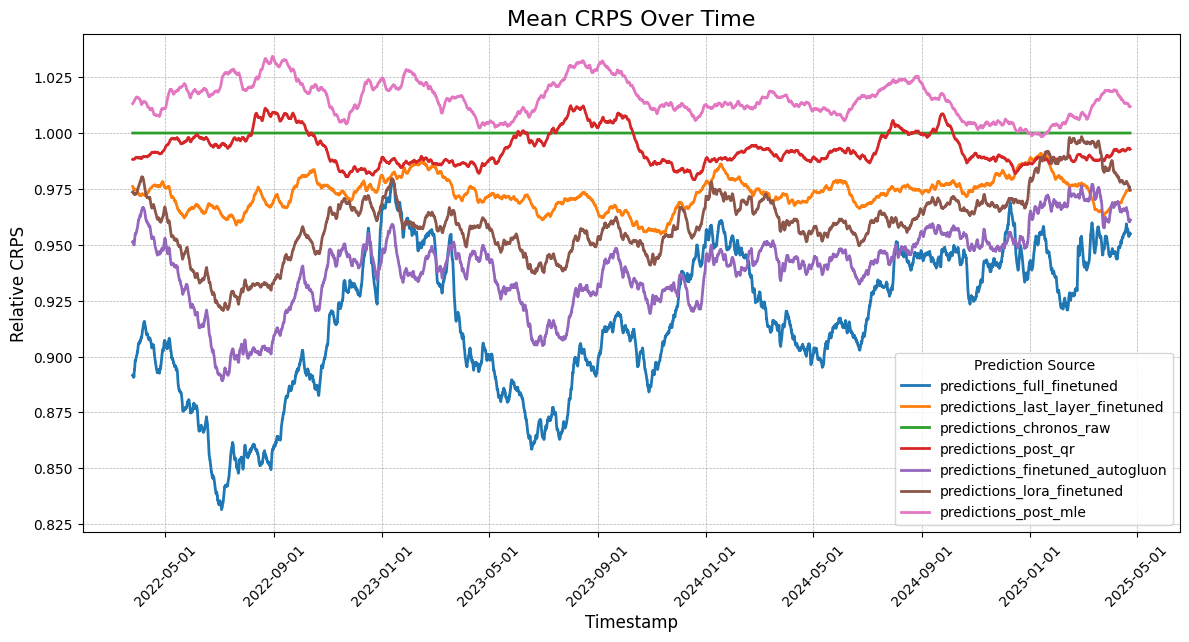

In [ ]:
plot_crps({k: all_predictions[k] for k in selected_keys}, rolling_window_eval=2000, reference_predictions="predictions_chronos_raw")

### Evaluation for individual model prediction (more details)

In [ ]:
predictions_raw.get_crps(lead_times=[1, 12, 24, 32, 48, 64], mean=True)

{'Mean CRPS Score': 3436.78}

In [ ]:
predictions_raw.get_quantile_scores(lead_times=[1, 12, 24, 32, 48, 64])

,1,12,24,32,48,64,QS averaged over all lead times
quantile,,,,,,,
0.1,281.06,999.10,1165.42,1273.94,1318.51,1376.24,1069.05
0.2,417.00,1510.41,1755.92,1951.83,2026.06,2121.92,1630.52
0.3,504.72,1829.20,2120.95,2374.42,2467.57,2584.93,1980.30
0.4,554.18,2000.92,2321.34,2603.57,2694.53,2826.18,2166.79
0.5,570.34,2045.00,2375.78,2655.95,2735.84,2869.26,2208.70
0.6,555.01,1967.60,2285.49,2537.47,2605.72,2734.61,2114.32
0.7,507.44,1765.87,2041.51,2247.49,2301.64,2418.28,1880.37
0.8,420.07,1424.42,1629.40,1773.75,1808.86,1907.49,1494.00
0.9,282.92,902.00,1007.73,1076.28,1097.99,1162.08,921.50


In [ ]:
predictions_raw.get_empirical_coverage_rates(lead_times=[1, 12, 24, 32, 48, 64])

,1,12,24,32,48,64,Empirical coverage rates averaged over all lead times
quantile,,,,,,,
0.1,0.04,0.12,0.11,0.11,0.11,0.11,0.10
0.2,0.14,0.22,0.21,0.20,0.21,0.20,0.20
0.3,0.26,0.31,0.31,0.29,0.30,0.29,0.29
0.4,0.39,0.40,0.41,0.38,0.39,0.38,0.39
0.5,0.52,0.49,0.49,0.47,0.49,0.47,0.49
0.6,0.65,0.58,0.59,0.56,0.58,0.57,0.59
0.7,0.77,0.67,0.68,0.65,0.68,0.67,0.69
0.8,0.88,0.78,0.78,0.76,0.78,0.78,0.79
0.9,0.96,0.89,0.90,0.88,0.90,0.90,0.90


<Figure size 800x800 with 0 Axes>

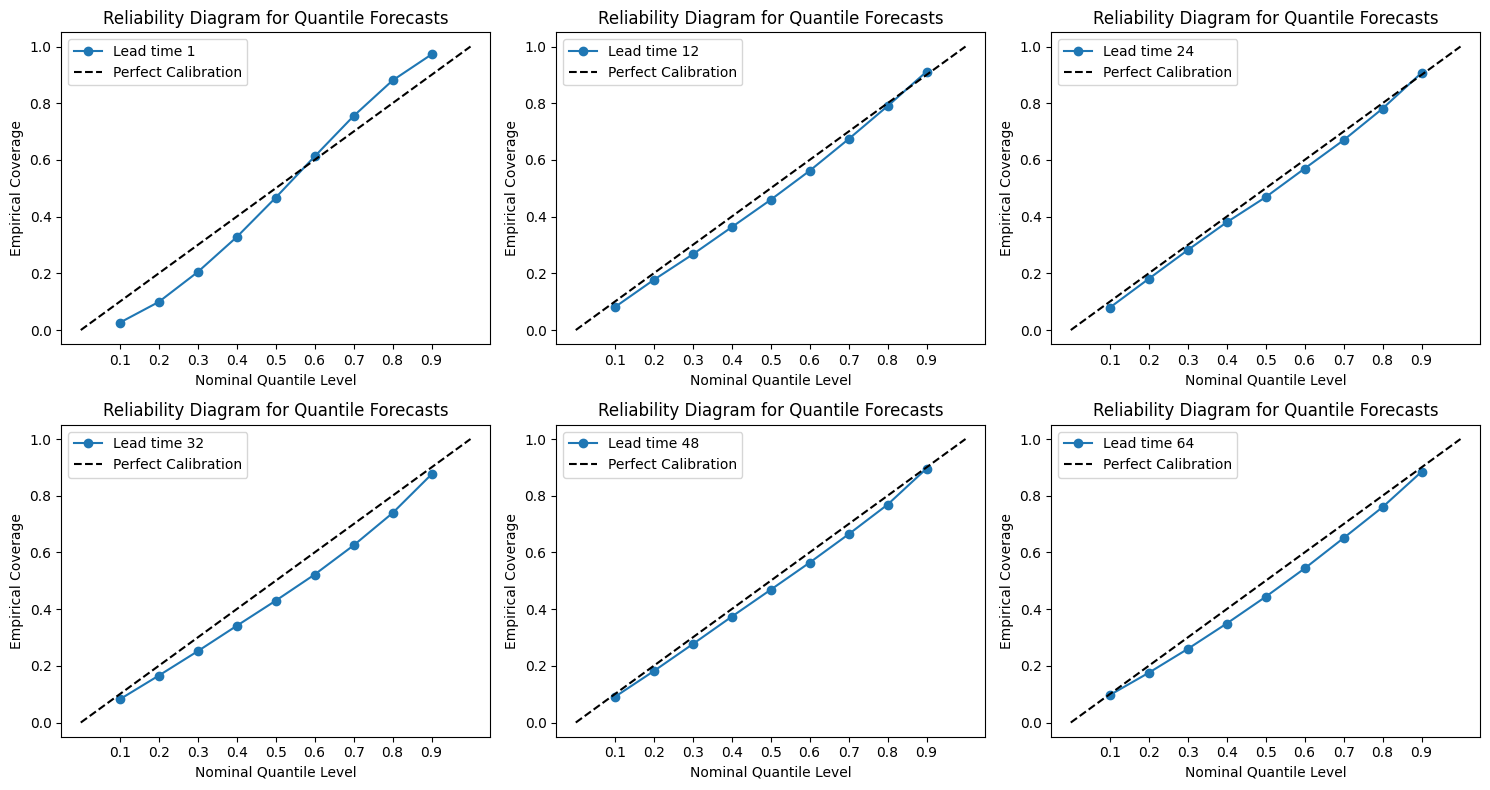

In [ ]:
predictions_raw.get_reliability_diagram(lead_times=[1, 12, 24, 32, 48, 64], item_ids=[0])

<Figure size 800x800 with 0 Axes>

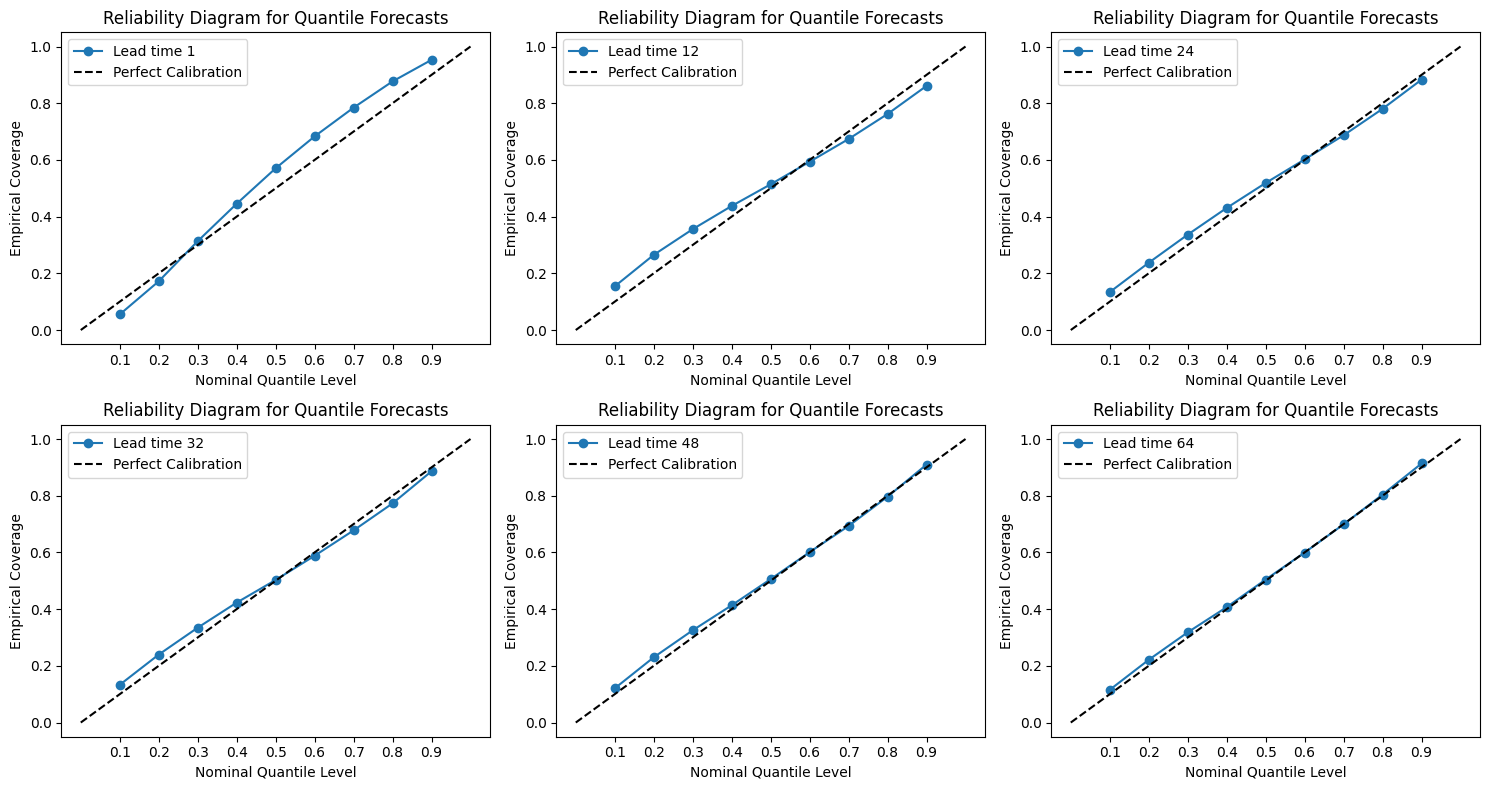

In [ ]:
predictions_raw.get_reliability_diagram(lead_times=[1, 12, 24, 32, 48, 64], item_ids=[1])

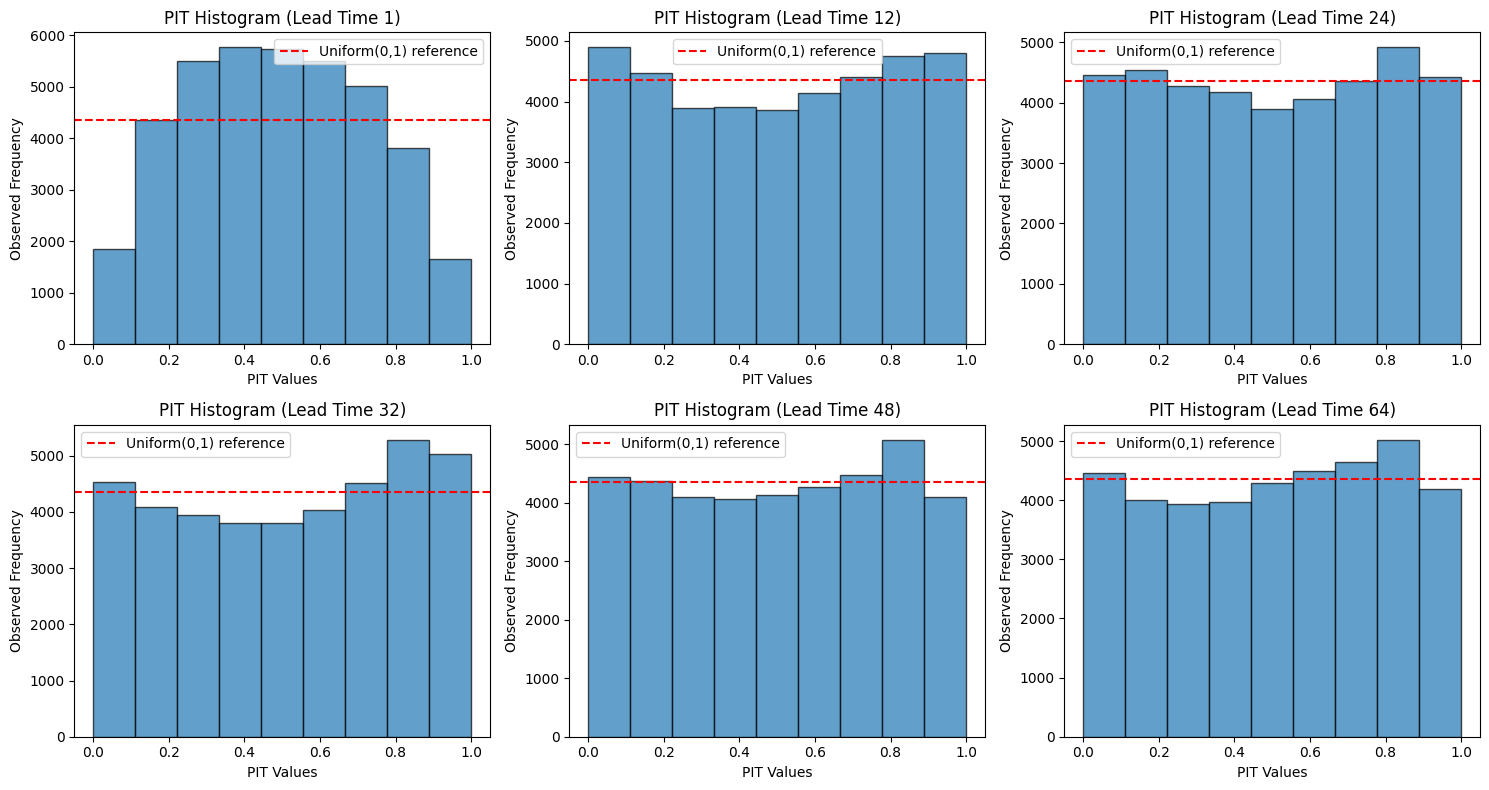

In [ ]:
predictions_raw.get_pit_histogram(lead_times=[1, 12, 24, 32, 48, 64])

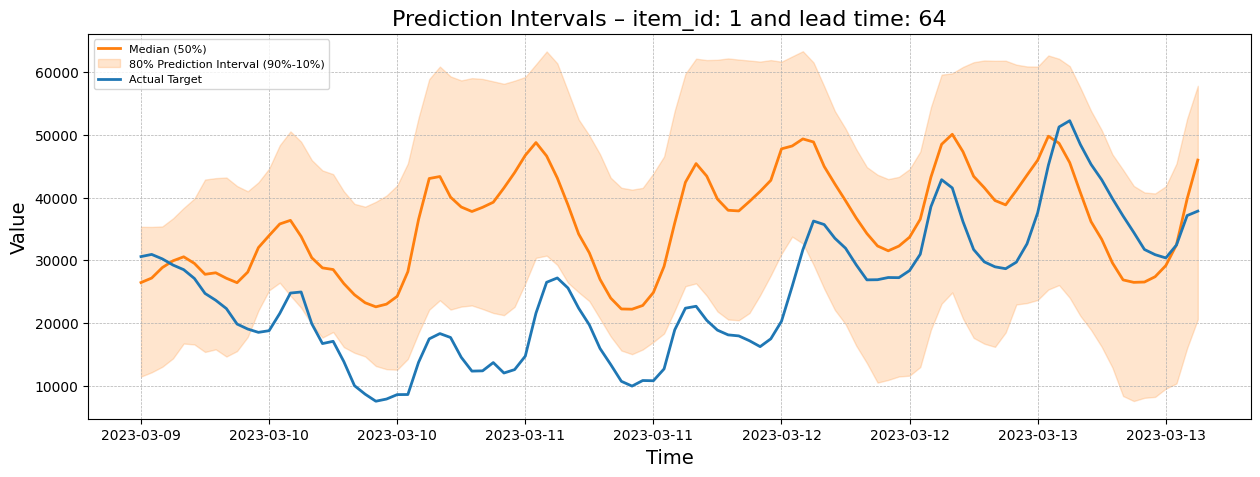

In [ ]:
predictions_benchmark_nn.results[64].get_random_plot(item_id=1)

# Additional Experiments

#### Compare chronos zero shot performance before and after 01-01-2023 against nn benchmark
- data used for training chronos goes until 2022. It might be that the gap between benchmark predictions and zero-shot chronos predictions increases after that.

In [ ]:
# create TimesSeriesDataFrame for convenience
data = TimeSeriesDataFrame(df)
data_train, data_test = data.split_by_time(pd.Timestamp("01-01-2020"))

lead_times = [1,4,8,12,24,36,48,60] # could also specify different ones
freq = pd.Timedelta("1h")

chronos = Chronos(model_name="amazon/chronos-bolt-tiny",
                  device_map="mps",
                  lead_times=lead_times,
                  freq=freq,
                  )

# get zero shot perdictions on test dataset
predictions_raw = chronos.predict(data=data_test,
                                  previous_context_data=data_train)

nn_predictor = NNPredictor(quantiles = np.arange(0.1, 1, 0.1),
                           lead_times=lead_times,
                           freq=freq)

nn_predictor.fit(data_train)
predictions_benchmark_nn = nn_predictor.predict(data_test)

all_predictions = {"chronos_predictions_raw": predictions_raw, "predictions_benchmark_nn": predictions_benchmark_nn}

Load chronos pipeline.


100%|██████████| 93108/93108 [00:19<00:00, 4886.58it/s]


In [ ]:
get_crps_by_period(all_predictions, 
                   lead_times=None, 
                   item_ids=None, 
                   reference_predictions="predictions_benchmark_nn",
                   date_splits=[ pd.Timestamp("01-01-2023")])

,chronos_predictions_raw,predictions_benchmark_nn
2020-01-01 00:00:00_to_2023-01-01 00:00:00,0.632009,1.0
2023-01-01 00:00:00_to_2025-04-23 23:00:00,0.629481,1.0
